# Literature

<img src="https://www.researchgate.net/publication/366287867/figure/fig1/AS:11431281107486430@1671074718081/The-TSVF-regime-Bandstructures-of-a-zigzag-and-b-bearded-graphene-with.ppm" alt="A Cat" width="800">

# Model

In [1]:
from topological_insulator import Problem

data_path = "../../topological_insulator/data/"
file_name = "honeycomb.json"

problem = Problem(data_path=data_path, file_name=file_name)

In [2]:
location = "edge"
problem.setup(
    N_r = 10, # size of lattice in real space
    N_k = 200, # reciprocal space discretization
    location = location,
    BZ = "reduced"
)

Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.


In [3]:
problem.model_options.solve_connectivity = True

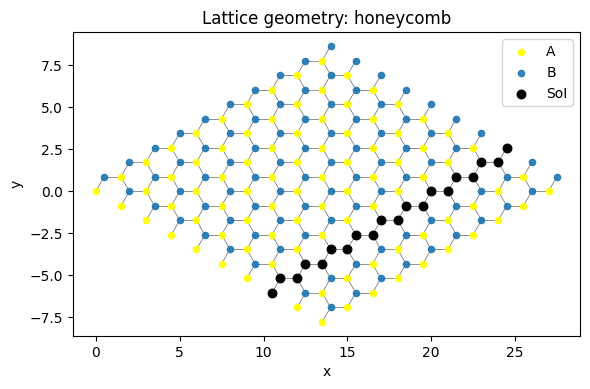

In [4]:
tb = problem.hamiltonian["edge"]["tight_binding"]
problem.geometry.plot_lattice(
    sites_of_interest=tb.sublattice_idxs
)

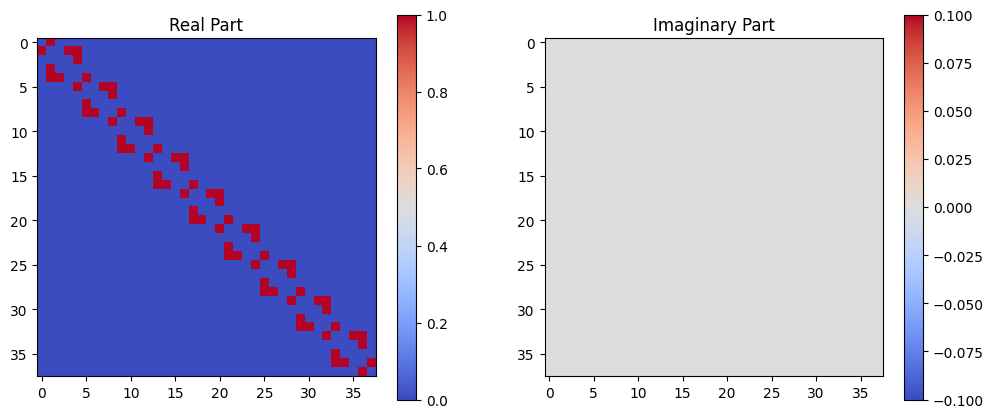

In [5]:
tb._visualise_matrix(tb.sublattice_connectivity)

In [6]:
problem.geometry.T

array([ 1.5      , -0.8660254])

## Bearded Zig-Zag Edge

In [7]:
problem.run(
    H_type="reciprocal"
)

Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done!


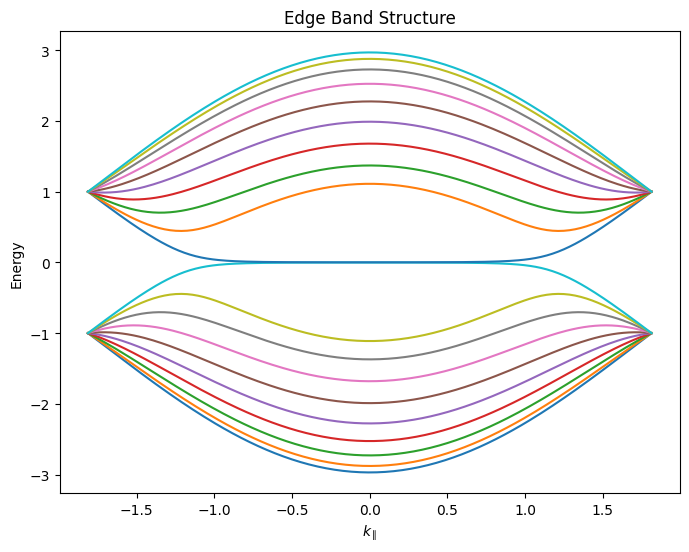

In [8]:
problem.plot(plot_type="dispersion", location=location)

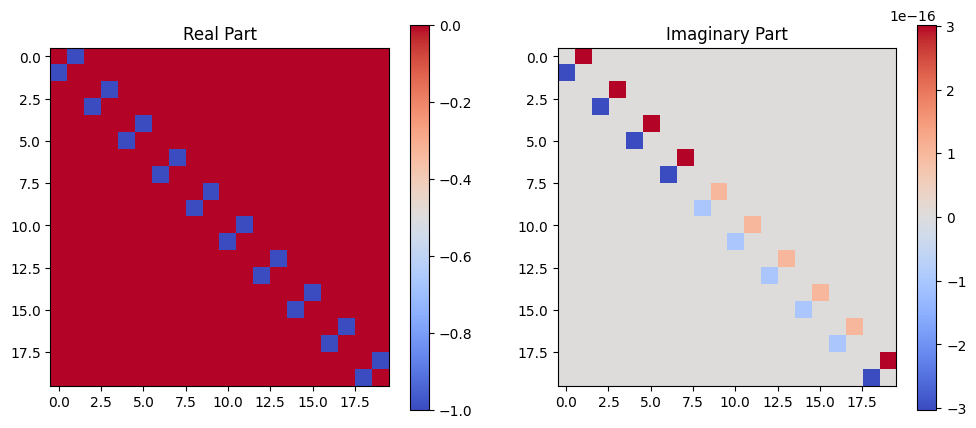

In [9]:
g = problem.geometry
k = g.k_edge[g.N_k - 1]
H_k = tb._fourier_transform(g, k)
tb._visualise_matrix(H_k)

## Zig-Zag Edge

In [10]:
import numpy as np
tb.sublattice_idxs = np.delete(tb.sublattice_idxs, [0, -1])

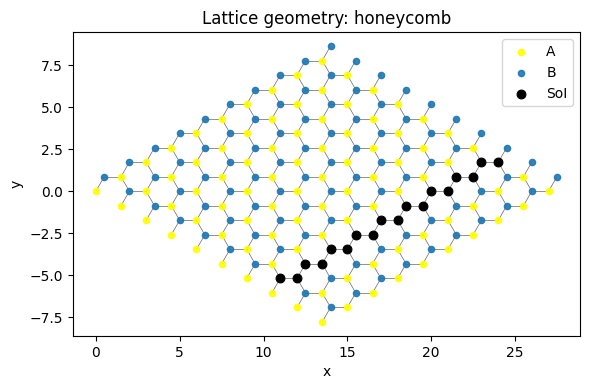

In [11]:
tb = problem.hamiltonian["edge"]["tight_binding"]
problem.geometry.plot_lattice(
    sites_of_interest=tb.sublattice_idxs
)

In [12]:
problem.run(
    H_type="reciprocal_space"
)

Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done!


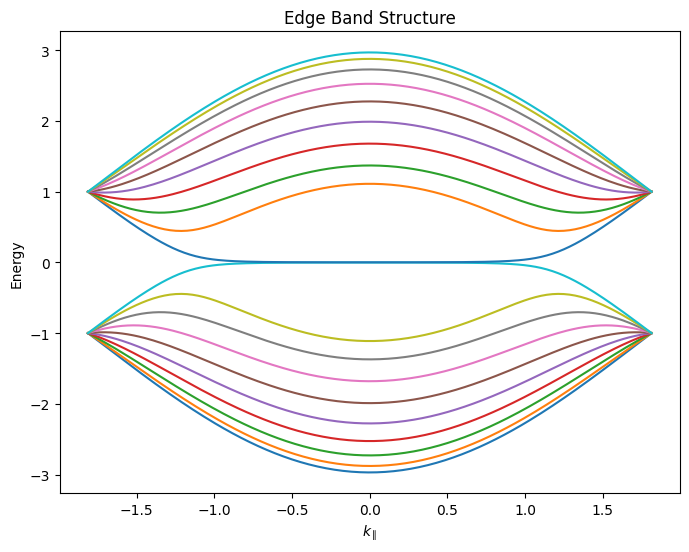

In [13]:
problem.plot(plot_type="dispersion", location=location)

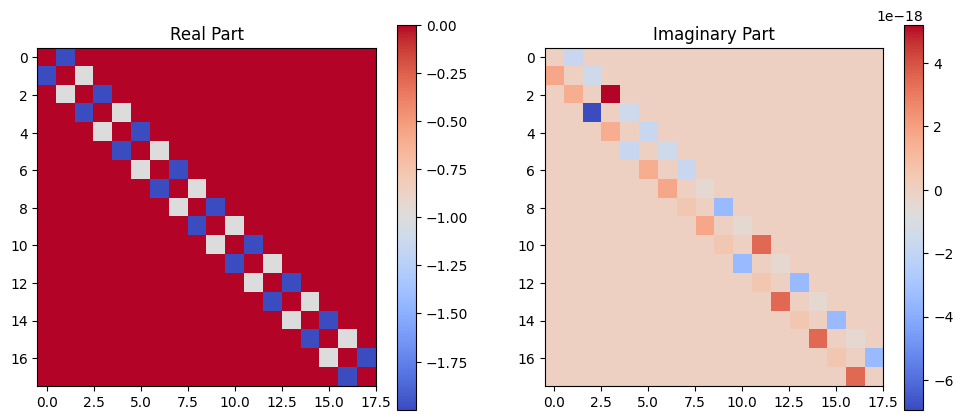

In [14]:
g = problem.geometry
k = g.k_edge[int(g.N_k/2) - 1]
H_k = tb._fourier_transform(g, k)
tb._visualise_matrix(H_k)